# Imports and dependencies

In [2]:
!pip install -q bertopic sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.8 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import re

from sentence_transformers import SentenceTransformer

from bertopic import BERTopic
from umap import UMAP

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import nltk
nltk.download("wordnet")
from nltk.stem import WordNetLemmatizer
nltk.download("stopwords")
from nltk.corpus import stopwords

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

# Dataset

In [5]:
df = pd.read_pickle("df_with_absa.pkl")
absa_df = pd.read_csv("absa_summary.csv")

print(f"Artículos: {len(df)}")
print(f"Columnas df: {df.columns.tolist()}")
print(f"Filas absa_df: {len(absa_df)}")
print(f"Columnas absa_df: {absa_df.columns.tolist()}")

Artículos: 80
Columnas df: ['id', 'url', 'title', 'text', 'lemmas', 'sentences', 'entities', 'entity_counts', 'entity_counts_norm', 'absa']
Filas absa_df: 400
Columnas absa_df: ['article_id', 'title', 'entity', 'entity_label', 'entity_count', 'n_sentences', 'polarity', 'NEG_pct', 'NEU_pct', 'POS_pct', 'mean_NEG', 'mean_POS']


# BERTopic

In [6]:
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = model.encode(df["text"].tolist(), show_progress_bar=True)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

In [7]:
# Unir lemas en string por documento
df["lemmas_str"] = df["lemmas"].apply(lambda x: " ".join(x))

english_stops = list(stopwords.words("english"))
vectorizer = CountVectorizer(stop_words=english_stops, min_df=2)

In [8]:
umap_model = UMAP(
    n_neighbors=5,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

topic_model = BERTopic(
    language="multilingual",
    min_topic_size=3,
    nr_topics="auto",
    umap_model=umap_model,
    vectorizer_model=vectorizer,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(df["lemmas_str"].tolist(), embeddings)
df["topic"] = topics
df["topic_prob"] = probs.max(axis=1)

print(df["topic"].value_counts().sort_index())

2026-06-22 21:50:15,543 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-22 21:50:26,523 - BERTopic - Dimensionality - Completed ✓
2026-06-22 21:50:26,524 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-22 21:50:26,542 - BERTopic - Cluster - Completed ✓
2026-06-22 21:50:26,543 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-22 21:50:27,074 - BERTopic - Representation - Completed ✓
2026-06-22 21:50:27,075 - BERTopic - Topic reduction - Reducing number of topics
2026-06-22 21:50:27,085 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-22 21:50:27,607 - BERTopic - Representation - Completed ✓
2026-06-22 21:50:27,610 - BERTopic - Topic reduction - Reduced number of topics from 6 to 6


topic
-1     6
 0    36
 1    13
 2    11
 3     9
 4     5
Name: count, dtype: int64


In [9]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,6,-1_iraq_saddam_iraqi_islamic,"[iraq, saddam, iraqi, islamic, law, iran, shar...",[sharia body islamic religious law base script...
1,0,36,0_woman_right_american_state,"[woman, right, american, state, include, viole...",[christian right christian political faction c...
2,1,13,1_russian_putin_russia_soviet,"[russian, putin, russia, soviet, marx, state, ...",[vladimir ilyich ulyanov 187021 january 1924 w...
3,2,11,2_al_hezbollah_israel_saudi,"[al, hezbollah, israel, saudi, attack, qaeda, ...",[september 11 attack colloquially know 9/11 se...
4,3,9,3_brown_reagan_album_jolie,"[brown, reagan, album, jolie, musk, film, pitt...",[john michael ozzy osbourne 3 december 1948 22...
5,4,5,4_khmer_rouge_genocide_tibet,"[khmer, rouge, genocide, tibet, tibetan, armen...",[november 1 1963 president ngô đình diệm perso...


In [9]:
df.loc[df["topic"] == -1]

,id,url,title,text,lemmas,sentences,entities,entity_counts,entity_counts_norm,absa,lemmas_str,topic,topic_prob
8,201936,https://en.wikipedia.org/wiki/2003_invasion_of...,2003 invasion of Iraq,The 2003 invasion of Iraq was the first stage ...,"[2003, invasion, iraq, stage, iraq, war, invas...",[The 2003 invasion of Iraq was the first stage...,"[{'text': 'Iraq', 'label': 'GPE'}, {'text': 't...","[((iraq, GPE), 216), ((iraqi, NORP), 177), ((u...","[((iraq, GPE), 216), ((iraqi, NORP), 194), ((u...","{('iraq', 'GPE'): {'count': 216, 'sentiment': ...",2003 invasion iraq stage iraq war invasion beg...,-1,0.160567
16,28840,https://en.wikipedia.org/wiki/Sharia,Sharia,Sharia () is the body of Islamic religious law...,"[sharia, body, islamic, religious, law, base, ...",[Sharia () is the body of Islamic religious la...,"[{'text': 'Islamic', 'label': 'NORP'}, {'text'...","[((islamic, NORP), 195), ((muslim, NORP), 113)...","[((islamic, NORP), 195), ((muslim, NORP), 150)...","{('islamic', 'NORP'): {'count': 195, 'sentimen...",sharia body islamic religious law base scriptu...,-1,0.191180
17,29490,https://en.wikipedia.org/wiki/Saddam_Hussein,Saddam Hussein,Saddam Hussein (28 April 1937 – 30 December 20...,"[saddam, hussein, 28, april, 1937, 30, decembe...",[Saddam Hussein (28 April 1937 – 30 December 2...,"[{'text': 'Saddam Hussein', 'label': 'PERSON'}...","[((saddam, PERSON), 254), ((iraq, GPE), 186), ...","[((saddam, PERSON), 254), ((iraq, GPE), 186), ...","{('saddam', 'PERSON'): {'count': 254, 'sentime...",saddam hussein 28 april 1937 30 december 2006 ...,-1,0.184503
27,415767,https://en.wikipedia.org/wiki/1953_Iranian_cou...,1953 Iranian coup d'état,"On 19 August 1953, Prime Minister of Iran Moha...","[19, august, 1953, prime, minister, iran, moha...","[On 19 August 1953, Prime Minister of Iran Moh...","[{'text': 'Iran', 'label': 'GPE'}, {'text': 'M...","[((iran, GPE), 137), ((mosaddegh, PERSON), 120...","[((iran, GPE), 137), ((mosaddegh, PERSON), 120...","{('iran', 'GPE'): {'count': 137, 'sentiment': ...",19 august 1953 prime minister iran mohammad mo...,-1,0.196089
35,802340,https://en.wikipedia.org/wiki/Anfal_campaign,Anfal campaign,The Anfal campaign was a counterinsurgency ope...,"[anfal, campaign, counterinsurgency, operation...",[The Anfal campaign was a counterinsurgency op...,"[{'text': 'Anfal', 'label': 'PERSON'}, {'text'...","[((anfal, PERSON), 47), ((kurdish, NORP), 35),...","[((anfal, PERSON), 47), ((iraqi, NORP), 35), (...","{('anfal', 'PERSON'): {'count': 47, 'sentiment...",anfal campaign counterinsurgency operation des...,-1,0.274371
62,106402,https://en.wikipedia.org/wiki/Genocide_denial,Genocide denial,Genocide denial is the attempt to deny or mini...,"[genocide, denial, attempt, deny, minimize, sc...",[Genocide denial is the attempt to deny or min...,"[{'text': 'Armenian', 'label': 'NORP'}, {'text...","[((armenian, NORP), 6), ((azerbaijan, GPE), 6)...","[((armenian, NORP), 11), ((azerbaijan, GPE), 6...","{('armenian', 'NORP'): {'count': 11, 'sentimen...",genocide denial attempt deny minimize scale se...,-1,0.365187


In [10]:
df.loc[df["id"] == 106402, "topic"] = 4
df.loc[df["topic"] == -1, "topic"] = 2

print(df["topic"].value_counts().sort_index())

topic
0    36
1    13
2    16
3     9
4     6
Name: count, dtype: int64


In [11]:
topic_labels = {
    0: "Controversias/miscelánea",
    1: "Política internacional",
    2: "Conflicto Oriente Medio",
    3: "Figuras públicas",
    4: "Genocidios"
}

for topic_id in sorted(df["topic"].unique()):
    titles = df[df["topic"] == topic_id]["title"].tolist()
    print(f"\nTopic {topic_id} — {topic_labels[topic_id]} ({len(titles)} artículos):")
    for t in titles:
        print(f"  - {t}")


Topic 0 — Controversias/miscelánea (36 artículos):
  - Abortion
  - Anarcho-capitalism
  - Mormonism
  - Native Americans in the United States
  - Family planning
  - Apartheid
  - HIV/AIDS denialism
  - Anti-Americanism
  - National-anarchism
  - Unidentified flying object
  - Veganism
  - Divorce
  - People for the Ethical Treatment of Animals
  - LGBTQ rights by country or territory
  - Vector Marketing
  - Christian right
  - Black supremacy
  - Criticism of Walmart
  - Scientology
  - Euthanasia
  - Eugenics
  - Healthcare reform in the United States
  - Same-sex marriage
  - Surrogacy
  - Domestic violence
  - Religion and LGBTQ people
  - Feminism
  - Female genital mutilation
  - Masculism
  - Homeopathy
  - Black Lives Matter
  - Christian Science
  - Self-harm
  - Anti-Christian sentiment
  - Islamophobia
  - Assisted suicide

Topic 1 — Política internacional (13 artículos):
  - Mikhail Gorbachev
  - Plame affair
  - Bashar al-Assad
  - Vladimir Putin
  - Chinese intelligenc

# TF-IDF per topic

In [12]:
def remove_verbs_from_lemmas_str(lemmas_string):
    # Split the string into individual lemmas
    lemmas = lemmas_string.split()

    # POS tag the lemmas
    tagged_lemmas = nltk.pos_tag(lemmas)

    # Filter out verbs (tags starting with 'VB')
    non_verb_lemmas = [lemma for lemma, tag in tagged_lemmas if not tag.startswith('VB')]

    return " ".join(non_verb_lemmas)

In [13]:
topic_lemmas = df.groupby("topic")["lemmas_str"].apply(" ".join).reset_index()

# Apply the verb removal function
topic_lemmas["filtered_lemmas_str"] = topic_lemmas["lemmas_str"].apply(remove_verbs_from_lemmas_str)

tfidf = TfidfVectorizer(max_features=100, stop_words=english_stops, min_df=1)
tfidf_matrix = tfidf.fit_transform(topic_lemmas["filtered_lemmas_str"]) # Use the filtered lemmas
terms = tfidf.get_feature_names_out()

top_terms = {}
for i, row in enumerate(tfidf_matrix.toarray()):
    top_idx = row.argsort()[-10:][::-1]
    topic_id = topic_lemmas.iloc[i]["topic"]
    top_terms[topic_id] = [terms[j] for j in top_idx]
    print(f"Topic {topic_id} — {topic_labels[topic_id]}: {top_terms[topic_id]}")

Topic 0 — Controversias/miscelánea: ['woman', 'state', 'american', 'right', 'abortion', 'people', 'country', 'new', 'divorce', 'violence']
Topic 1 — Política internacional: ['putin', 'russian', 'state', 'government', 'soviet', 'russia', 'war', 'report', 'intelligence', 'election']
Topic 2 — Conflicto Oriente Medio: ['hamas', 'al', 'hezbollah', 'iraq', 'islamic', 'state', 'war', 'attack', 'israel', 'government']
Topic 3 — Figuras públicas: ['year', 'later', 'time', 'state', 'black', 'new', 'work', 'support', 'child', 'million']
Topic 4 — Genocidios: ['state', 'government', 'people', 'soviet', '000', 'million', 'death', 'general', 'force', 'war']


## Visualization

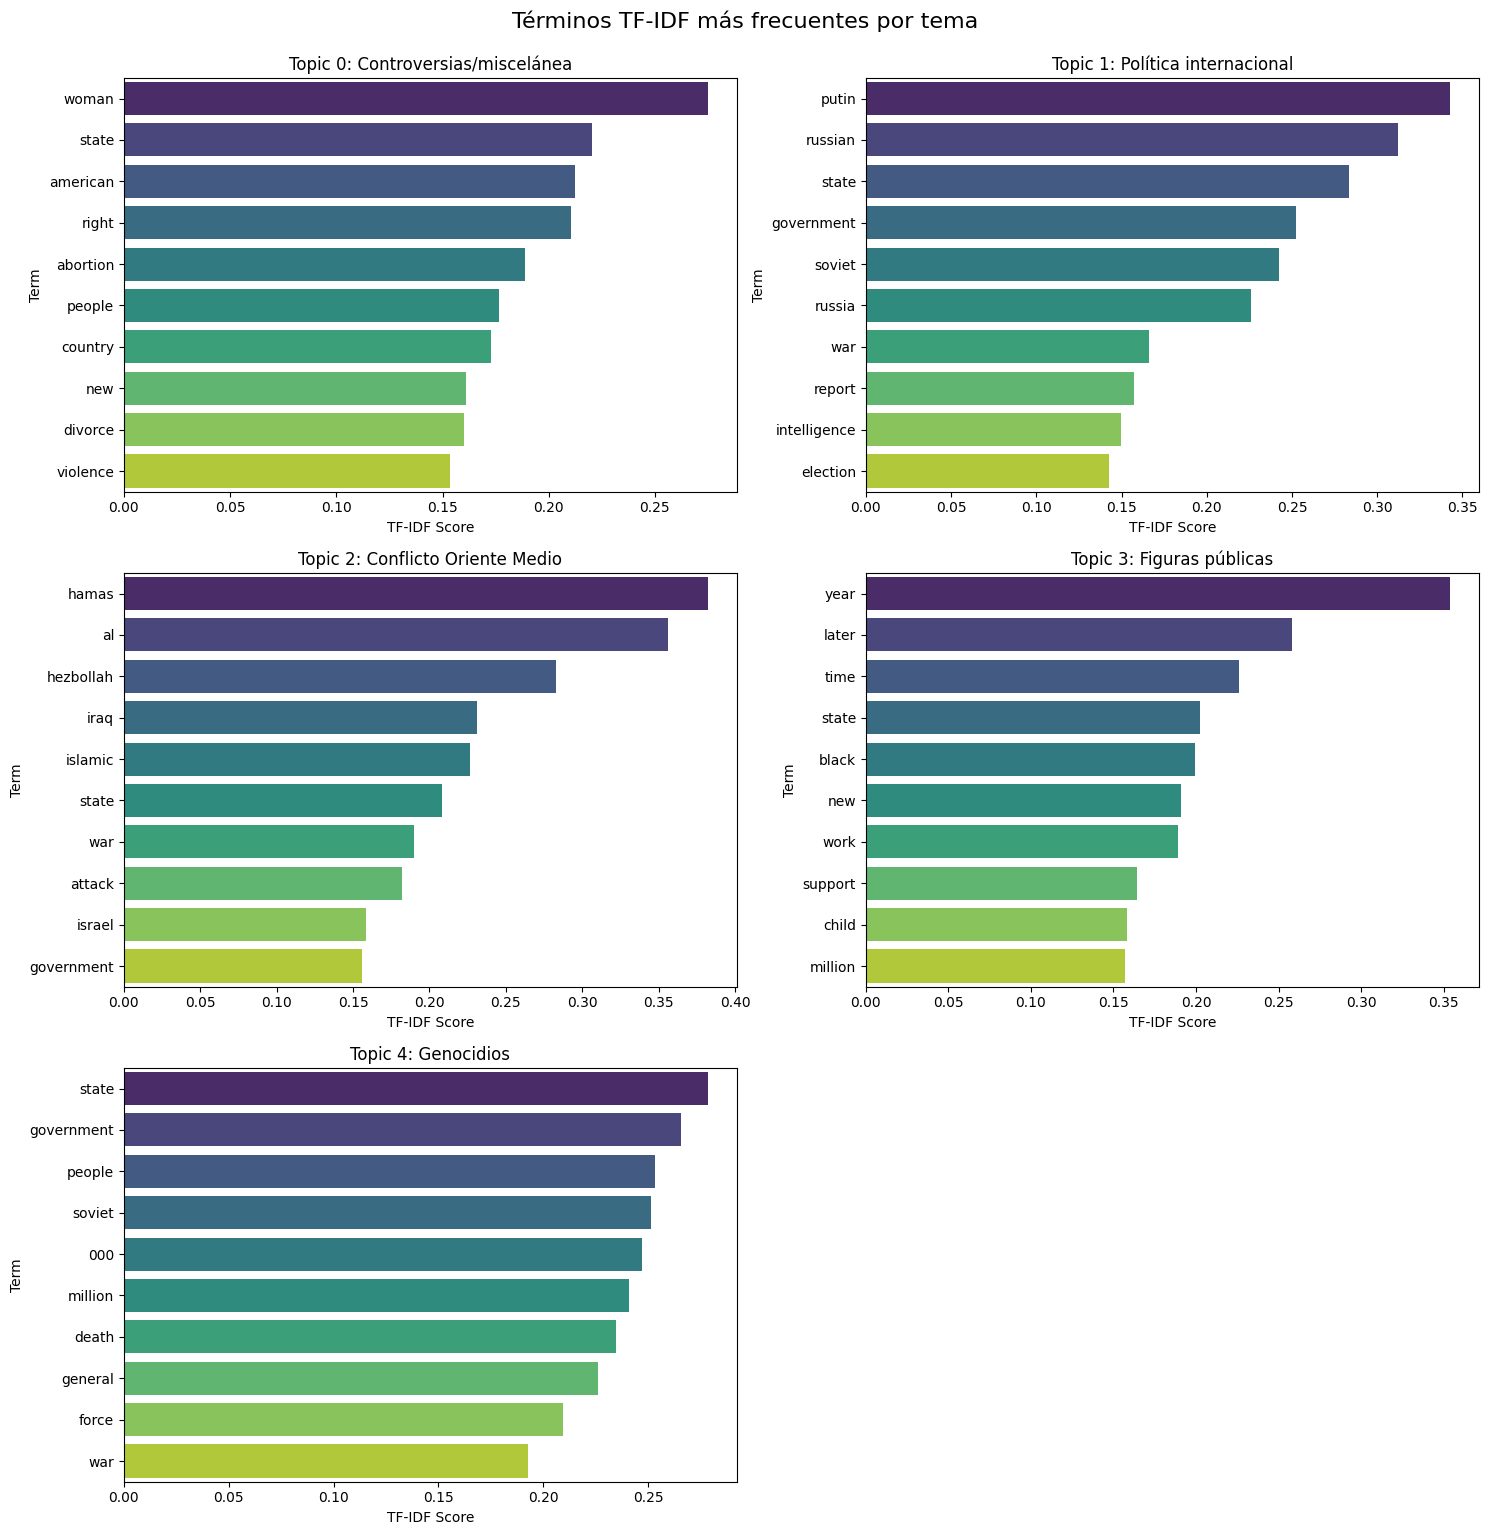

In [14]:
# Prepare data for plotting
plot_data = []
for topic_id, terms_list in top_terms.items():
    # Get the corresponding TF-IDF scores for the top terms in this topic
    topic_idx = topic_lemmas[topic_lemmas["topic"] == topic_id].index[0]
    scores = tfidf_matrix[topic_idx, :].toarray().flatten()

    # Map terms to their scores for the current topic
    term_scores = {terms[j]: scores[j] for j in scores.argsort()[-10:][::-1]}

    for term in terms_list:
        plot_data.append({"topic_id": topic_id, "term": term, "tfidf_score": term_scores.get(term, 0)})

plot_df = pd.DataFrame(plot_data)

# Create subplots for each topic
num_topics = len(df["topic"].unique())
fig, axes = plt.subplots(nrows=int(np.ceil(num_topics / 2)), ncols=2, figsize=(15, 5 * int(np.ceil(num_topics / 2))))
axes = axes.flatten()

for i, topic_id in enumerate(sorted(plot_df["topic_id"].unique())):
    ax = axes[i]
    subset = plot_df[plot_df["topic_id"] == topic_id].sort_values("tfidf_score", ascending=False)
    sns.barplot(x="tfidf_score", y="term", data=subset, ax=ax, palette="viridis")
    ax.set_title(f"Topic {topic_id}: {topic_labels[topic_id]}")
    ax.set_xlabel("TF-IDF Score")
    ax.set_ylabel("Term")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Términos TF-IDF más frecuentes por tema", y=1.02, fontsize=16)
plt.show()

In [15]:
lemmatizer = WordNetLemmatizer()

for topic_id in sorted(df["topic"].unique()):
    print(f"\n{'='*60}")
    print(f"TOPIC {topic_id} — {topic_labels[topic_id]}")
    print(f"Top terms: {top_terms[topic_id][:5]}")
    print('='*60)

    topic_docs = df[df["topic"] == topic_id]

    for term in top_terms[topic_id][:5]:
        print(f"\n  ['{term}']")
        unique_article_hits = []
        articles_with_examples = set()

        for _, row in topic_docs.iterrows():
            # Stop collecting examples for this term if we already have 2 from different articles
            if len(articles_with_examples) >= 2:
                break

            title = row["title"]
            # If we already have an example from this article, skip it for this term
            if title in articles_with_examples:
                continue

            # Search for the term in sentences of the current article
            for sent in row["sentences"]:
                words = sent.lower().split()
                lemmas_sent = [lemmatizer.lemmatize(w) for w in words]
                if term in lemmas_sent:
                    unique_article_hits.append((title, sent))
                    articles_with_examples.add(title)
                    break # Move to the next article once an example is found for this term

        # Print the collected unique article hits
        for title, sent in unique_article_hits:
            print(f"  [{title}] → {sent}")


TOPIC 0 — Controversias/miscelánea
Top terms: ['woman', 'state', 'american', 'right', 'abortion']

  ['woman']
  [Abortion] → When performed legally and safely on a woman who desires it, an induced abortion does not increase the risk of long-term mental or physical problems.
  [Native Americans in the United States] → Professor Sarah Deer highlights the high number of Native women who still experience this violence: "Since 1999 a variety of reports and studies have come to the same conclusion- namely, that Native women in particular suffer the highest rate of per capita rape in the US."

  ['state']
  [Abortion] → The World Health Organization states that "access to legal, safe and comprehensive abortion care, including post-abortion care, is essential for the attainment of the highest possible level of sexual and reproductive health".
  [Anarcho-capitalism] → Anarcho-capitalism argues that a society can function without a state through voluntary exchange and private institutions that

# ABSA merge with topic

In [16]:
topic_map = df[["title", "topic"]].drop_duplicates()

# Eliminar columnas de topic previas si existen
cols_to_drop = [c for c in absa_df.columns if "topic" in c]
absa_df = absa_df.drop(columns=cols_to_drop)

absa_df = absa_df.merge(topic_map, on="title", how="left")

print(absa_df.shape)
print(absa_df["topic"].value_counts().sort_index())

(400, 13)
topic
0    180
1     65
2     80
3     45
4     30
Name: count, dtype: int64


In [17]:
topic_absa = absa_df.groupby(["topic", "entity"]).agg(
    total_sentences=("n_sentences", "sum"),
    mean_polarity=("polarity", "mean"),
    mean_POS=("mean_POS", "mean"),
    mean_NEG=("mean_NEG", "mean"),
    doc_count=("title", "nunique")
).reset_index()

print(topic_absa.shape)

for topic_id in sorted(topic_absa["topic"].unique()):
    print(f"\n{'='*60}")
    print(f"TOPIC {topic_id} — {topic_labels[topic_id]}")
    print('='*60)
    subset = (topic_absa[topic_absa["topic"] == topic_id]
              .sort_values("total_sentences", ascending=False)
              .head(10))
    print(subset[["entity", "total_sentences", "mean_polarity", "mean_POS", "mean_NEG"]].to_string(index=False))

(283, 7)

TOPIC 0 — Controversias/miscelánea
       entity  total_sentences  mean_polarity  mean_POS  mean_NEG
united states              587      -0.086393  0.026423  0.112816
     american              225      -0.175889  0.036428  0.212317
    christian              153      -0.129029  0.091882  0.220911
        lgbtq              120       0.080187  0.322706  0.242519
         peta              100      -0.183786  0.103289  0.287075
       indian               81      -0.163123  0.022656  0.185779
 south africa               71      -0.108584  0.024011  0.132595
    hahnemann               66      -0.140596  0.092271  0.232867
south african               62      -0.244657  0.040380  0.285037
       muslim               58      -0.401807  0.032303  0.434110

TOPIC 1 — Política internacional
          entity  total_sentences  mean_polarity  mean_POS  mean_NEG
   united states              307      -0.293712  0.039569  0.333281
          soviet              175      -0.325124  0.05287

##Visualization

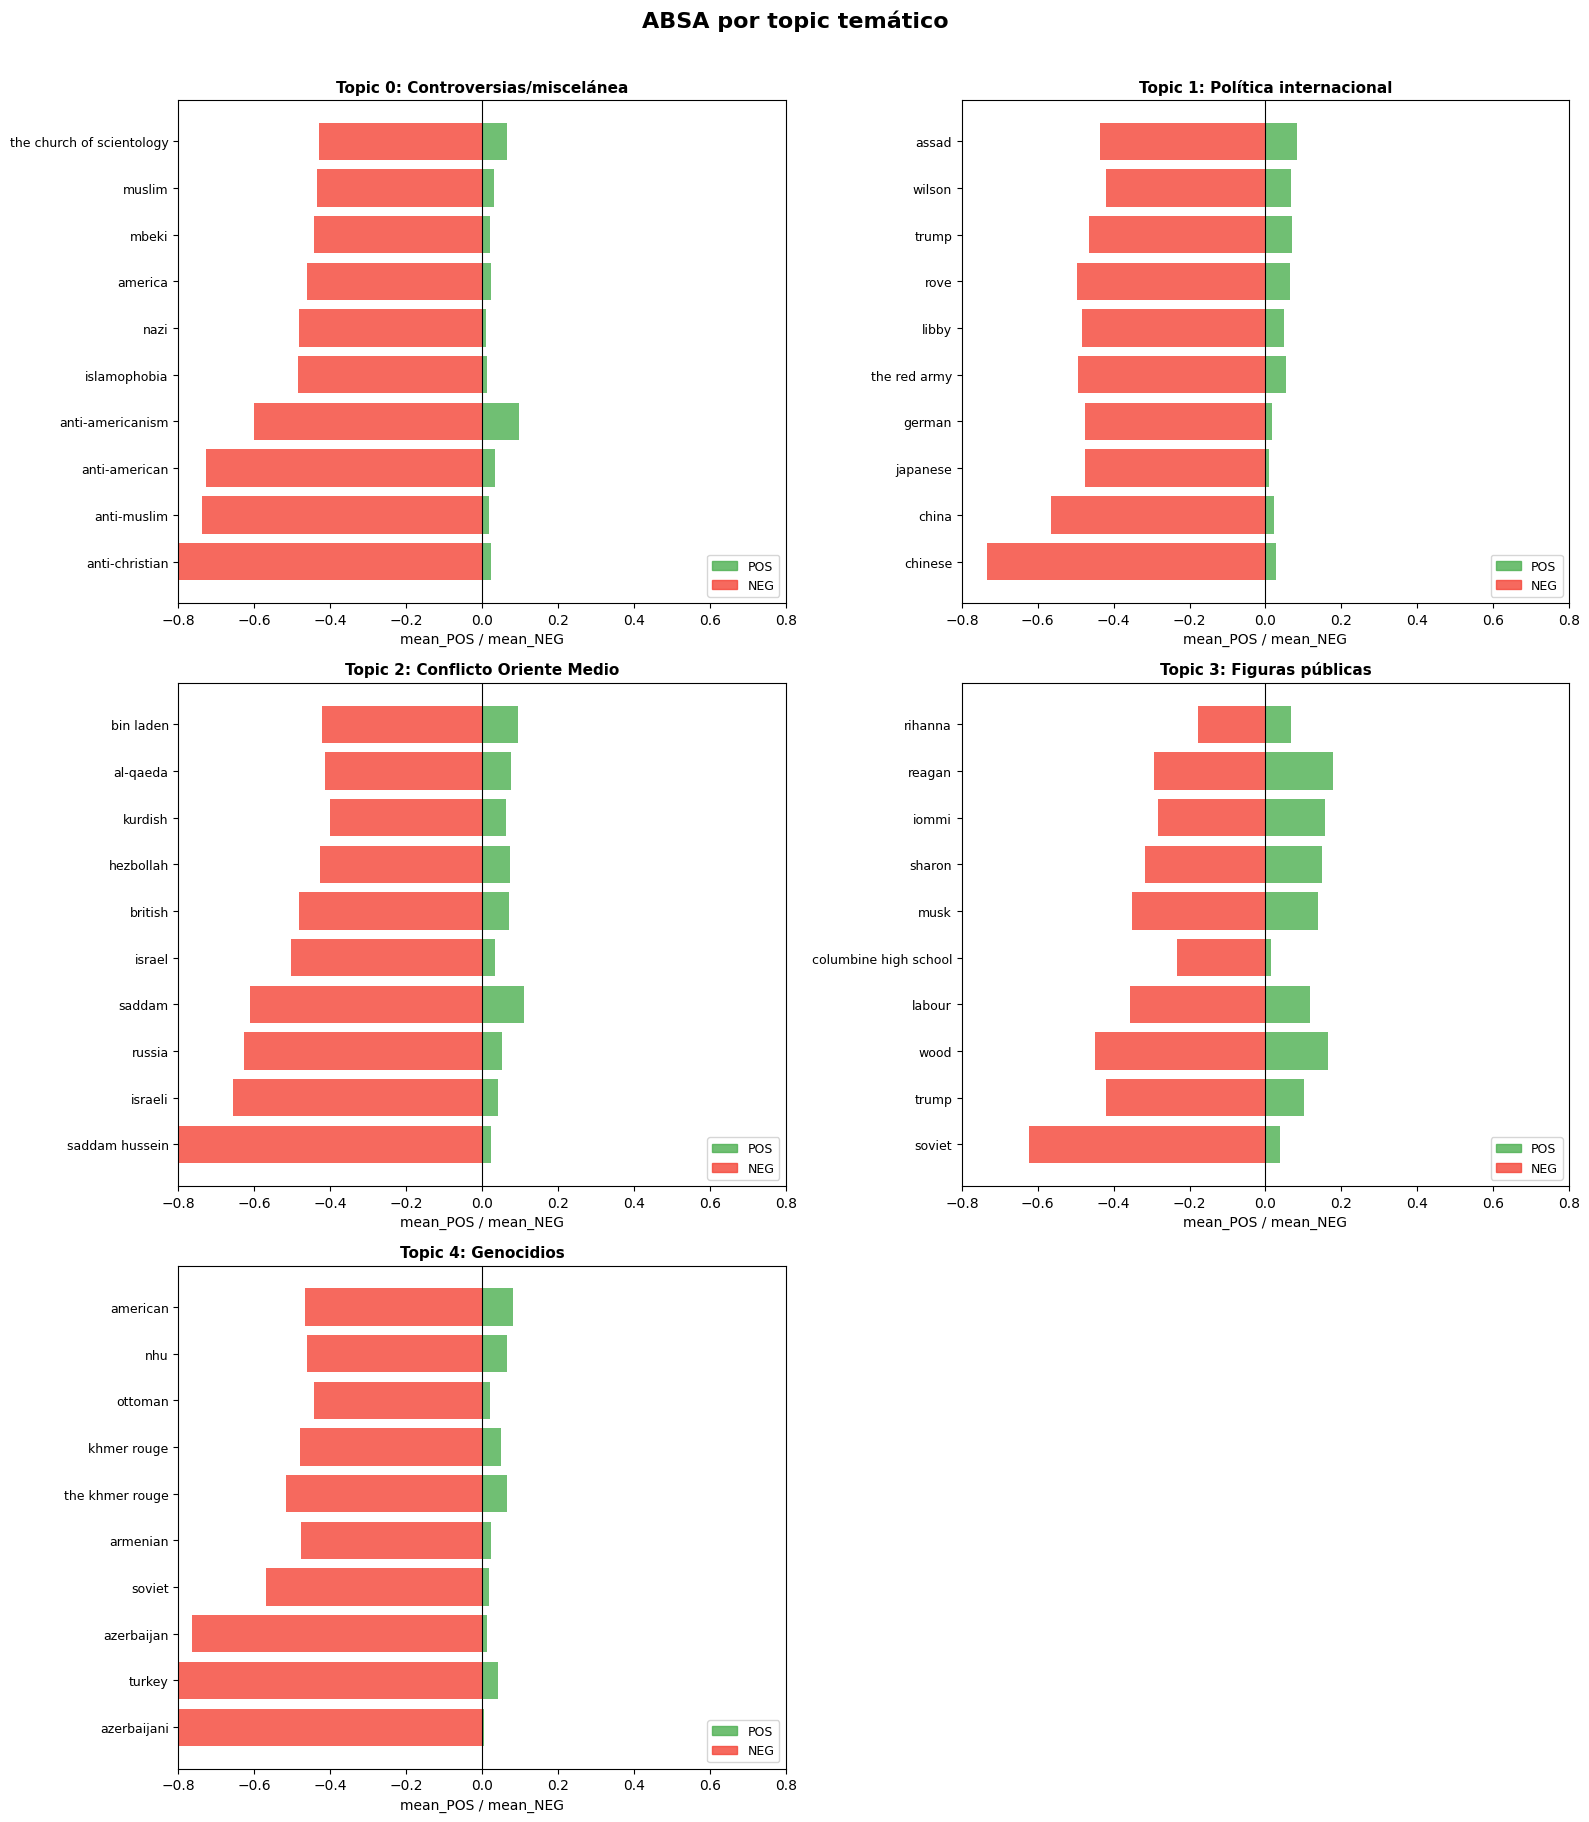

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("ABSA por topic temático", fontsize=16, fontweight="bold", y=1.01)
axes = axes.flatten()
colors = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261"]

pos_patch = mpatches.Patch(color="#4CAF50", alpha=0.8, label="POS")
neg_patch = mpatches.Patch(color="#F44336", alpha=0.8, label="NEG")

for i, topic_id in enumerate(sorted(topic_absa["topic"].unique())):
    ax = axes[i]
    # Sort entities by mean_polarity from negative to positive
    subset = (topic_absa[topic_absa["topic"] == topic_id]
              .sort_values("mean_polarity", ascending=True)
              .head(10))

    entities = subset["entity"].tolist()
    pos = subset["mean_POS"].tolist()
    neg = [-v for v in subset["mean_NEG"].tolist()]

    y = np.arange(len(entities))
    ax.barh(y, pos, color="#4CAF50", alpha=0.8)
    ax.barh(y, neg, color="#F44336", alpha=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(entities, fontsize=9)
    ax.set_title(f"Topic {topic_id}: {topic_labels[topic_id]}", fontsize=11, fontweight="bold")
    ax.set_xlabel("mean_POS / mean_NEG")
    ax.set_xlim(-0.8, 0.8)
    ax.legend(handles=[pos_patch, neg_patch], loc="lower right", fontsize=9)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("absa_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

### Correlation between People topic and mean polarity

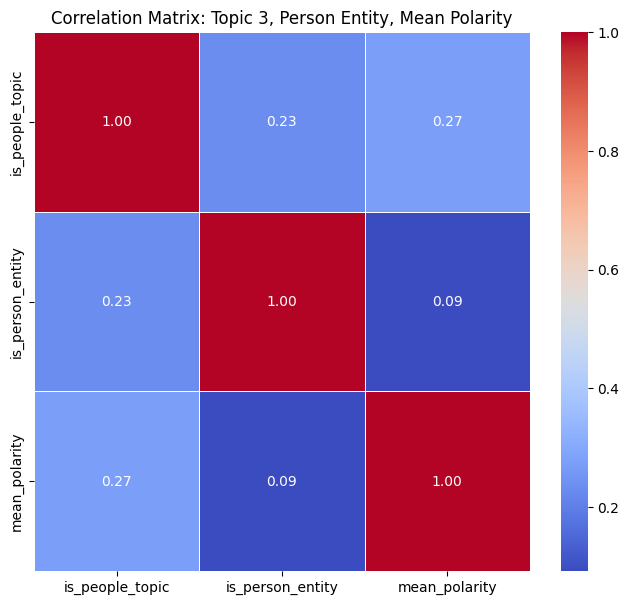

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Re-create topic_absa to ensure it's defined in case of kernel reset or partial execution
# This assumes absa_df is defined from earlier executed cells (e.g., cell 22).
topic_absa = absa_df.groupby(["topic", "entity", "entity_label"]).agg(
    total_sentences=("n_sentences", "sum"),
    mean_polarity=("polarity", "mean"),
    mean_POS=("mean_POS", "mean"),
    mean_NEG=("mean_NEG", "mean"),
    doc_count=("title", "nunique")
).reset_index()

# Create a binary variable for 'Figuras públicas' (Topic 3)
topic_absa['is_people_topic'] = (topic_absa['topic'] == 3).astype(int)

# Create a binary variable for 'PERSON' entity label
topic_absa['is_person_entity'] = (topic_absa['entity_label'] == 'PERSON').astype(int)

# Select the relevant columns for correlation
correlation_data = topic_absa[['is_people_topic', 'is_person_entity', 'mean_polarity']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Display the correlation matrix using a heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix: Topic 3, Person Entity, Mean Polarity')
plt.show()

In [19]:
for topic_id in sorted(df["topic"].unique()):
    print(f"\n{'='*60}")
    print(f"TOPIC {topic_id} — {topic_labels[topic_id]}")
    print(f"{'='*60}")

    topic_articles = df[df["topic"] == topic_id]
    # Get unique entities for the current topic from topic_absa
    entities_in_topic = topic_absa[topic_absa["topic"] == topic_id]["entity"].unique()

    for entity in entities_in_topic:
        # Compile regex for whole word matching, case-insensitive
        entity_regex = re.compile(r'\b' + re.escape(entity.lower()) + r'\b')

        print(f"\n  ['{entity}']")
        extracted_sentences_count = 0
        articles_with_examples = set()

        for _, article_row in topic_articles.iterrows():
            if extracted_sentences_count >= 2:
                break # Stop if we have two sentences for this entity

            article_title = article_row["title"]
            if article_title in articles_with_examples:
                continue # Skip if we already took a sentence from this article for this entity

            for sentence in article_row["sentences"]:
                if entity_regex.search(sentence.lower()):
                    print(f"  [{article_title}] -> {sentence}")
                    extracted_sentences_count += 1
                    articles_with_examples.add(article_title)
                    break # Move to the next article to find another sentence for this entity

                if extracted_sentences_count >= 2:
                    break # Stop if we have two sentences for this entity


TOPIC 0 — Controversias/miscelánea

  ['aca']
  [Criticism of Walmart] -> Experts in labor and health care observed that the change will shift the burden of providing health care for Walmart employees to the federal government, as eligibility for Medicaid has been expanded under the Patient Protection and Affordable Care Act (PPACA or ACA).
  [Healthcare reform in the United States] -> The Patient Protection and Affordable Care Act, called PPACA or ACA but also known as Obamacare, was enacted, including the following provisions:
 the phased introduction over multiple years of a comprehensive system of mandated health insurance reforms designed to eliminate "some of the worst practices of the insurance companies"—pre-existing condition screening and premium loadings, policy cancellations on technicalities when illness seems imminent, annual and lifetime coverage caps
 Expanded Medicaid to cover uninsured working-age adults (18-65) earning under 138% of the Federal Poverty Line (and the

## Saving data

In [20]:
df.to_pickle("03_df_with_topics.pkl")
absa_df.to_csv("03_absa_with_topics.csv", index=False)
topic_absa.to_csv("03_topic_absa_aggregated.csv", index=False)